In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('q2_customers.csv')

# Display first few rows
print(df.head())

# Features
X = df[['age', 'annual_spend', 'visits_per_month',
        'basket_size', 'days_since_last_visit',
        'num_categories_purchased']]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  


Markdown (Explanation)

Why scaling is important before K-Means:

K-Means uses distance (Euclidean distance) to form clusters. If features are on different scales (e.g., age vs annual spend), larger-scale features dominate clustering.

Scaling ensures:

All features contribute equally
Distance calculations are meaningful
Clusters are not biased toward high-value features

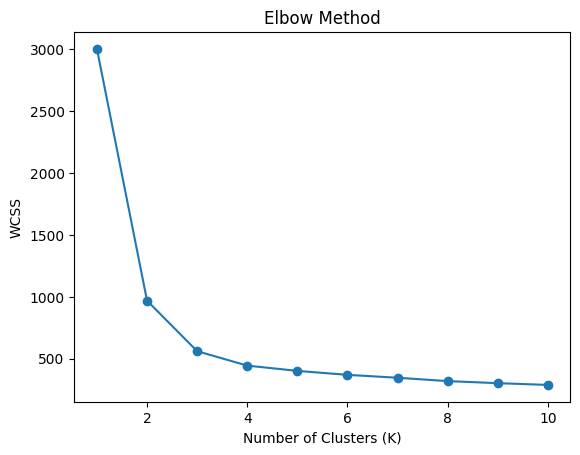

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

# Compute WCSS for K = 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

Markdown (Explanation)

The Elbow Method plots WCSS vs K.

WCSS measures how compact clusters are (lower is better)
As K increases, WCSS decreases
The optimal K is where the curve bends ("elbow")

In [4]:
# Choose optimal K
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=X.columns
)

print("Cluster Centroids:")
print(centroids)

Cluster Centroids:
         age  annual_spend  visits_per_month  basket_size  \
0  24.676471  14847.370588         14.341176   558.970588   
1  56.769697  89413.333333          2.527273  5530.545455   
2  40.387879  43340.733333          8.193939  2021.684848   

   days_since_last_visit  num_categories_purchased  
0               9.076471                  2.111765  
1             105.357576                  7.515152  
2              35.187879                  4.424242  


Markdown (Interpretation Example)
Cluster 0: Young customers, low spending, frequent visits → budget frequent shoppers
Cluster 1: High spend, large basket size → premium customers
Cluster 2: Infrequent visits, long gaps → inactive or churn-risk customers

In [5]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

# Loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=['PC1', 'PC2']
)

print("\nFeature Loadings:")
print(loadings)

Explained Variance Ratio:
[0.83560354 0.05568764]

Feature Loadings:
          age  annual_spend  visits_per_month  basket_size  \
PC1  0.411569       0.42154         -0.410399     0.412012   
PC2 -0.259432      -0.03327          0.208318    -0.195402   

     days_since_last_visit  num_categories_purchased  
PC1               0.378582                  0.414017  
PC2               0.911194                 -0.140479  


Markdown (Interpretation)
PC1: Usually represents overall customer value (spend, basket size)
PC2: Often reflects behavior (visits, recency)

 Interpretation depends on highest absolute loadings:

High spend + basket → value dimension
Visits + recency → engagement dimension

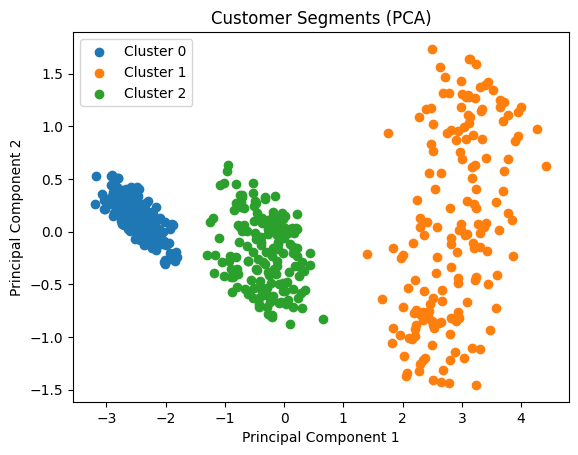

In [6]:
plt.figure()

# Scatter plot
for cluster in range(optimal_k):
    plt.scatter(
        X_pca[df['cluster'] == cluster, 0],
        X_pca[df['cluster'] == cluster, 1],
        label=f'Cluster {cluster}'
    )

plt.title('Customer Segments (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()